OpenCV version: 5.0.0

Upload TWO images:
1. Reference sports-field image
2. Broadcast sports-field image


Saving football broadcast.jpg to football broadcast.jpg
Saving football overhead.jpg to football overhead.jpg

Uploaded files:
- football broadcast.jpg
- football overhead.jpg

Reference image size: 1920 x 1080
Broadcast image size: 2048 x 1365

========== SIFT FEATURE DETECTION ==========
Reference keypoints: 3000
Broadcast keypoints: 3000


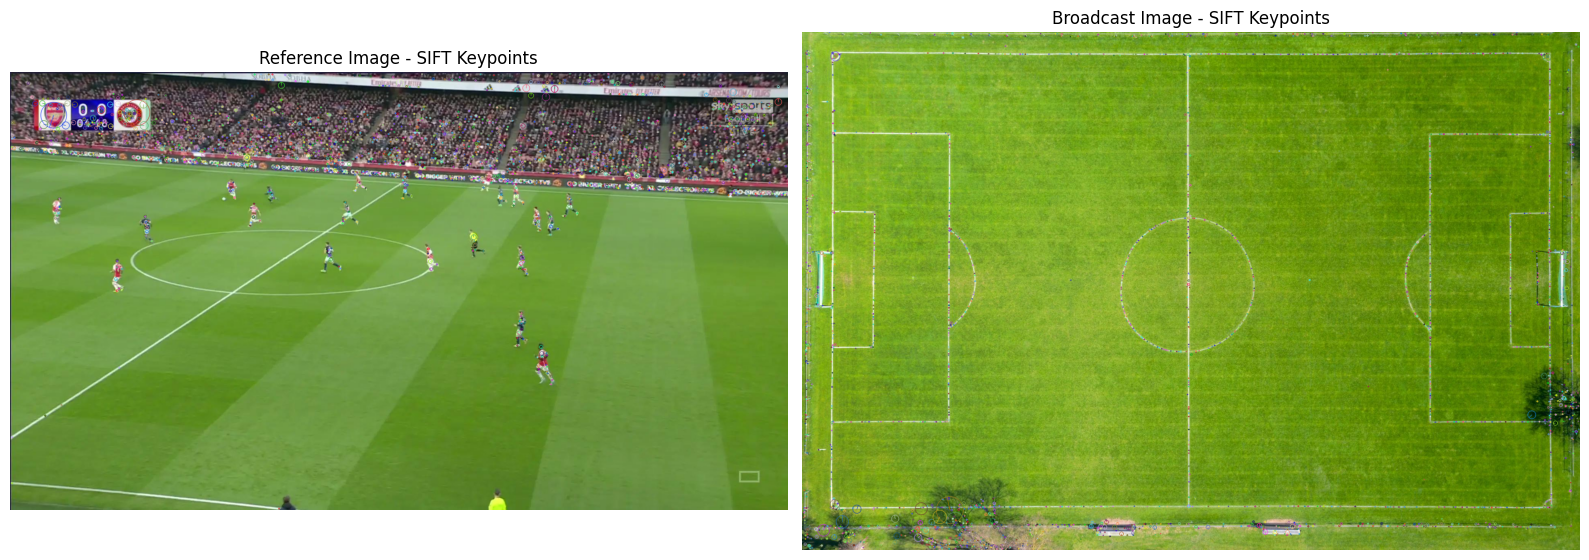


========== FEATURE MATCHING ==========
Total candidate matches: 3000
Good matches after Lowe's ratio test: 10


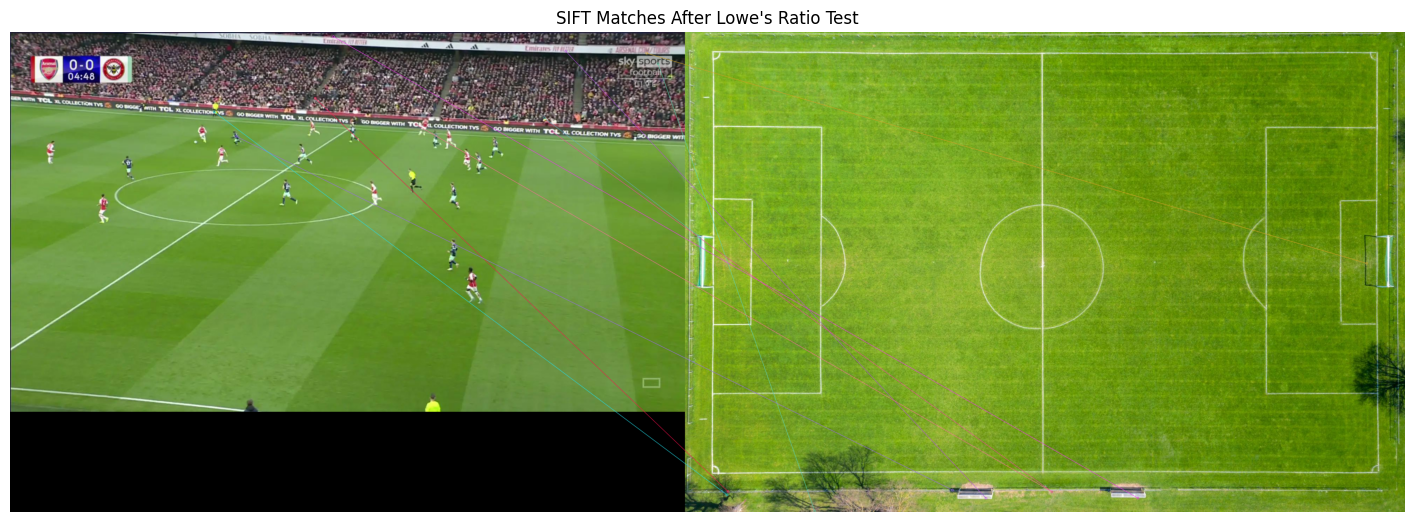


========== RANSAC RESULTS ==========
Good matches: 10
RANSAC inliers: 4
RANSAC outliers: 6
Inlier ratio: 0.4000
Inlier ratio (%): 40.00%


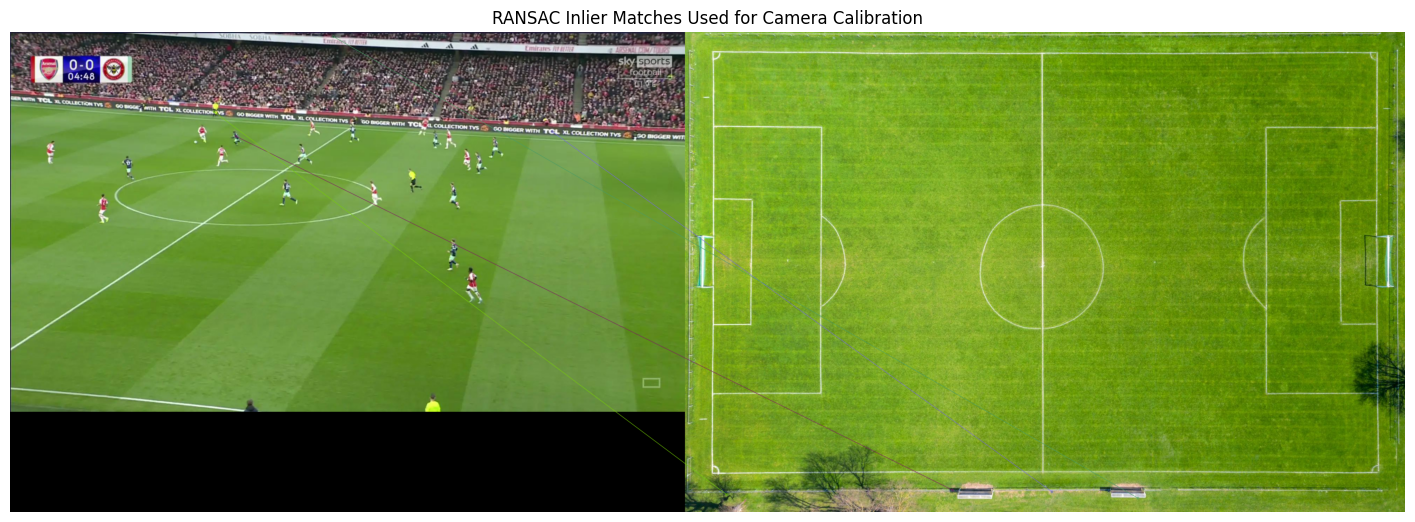

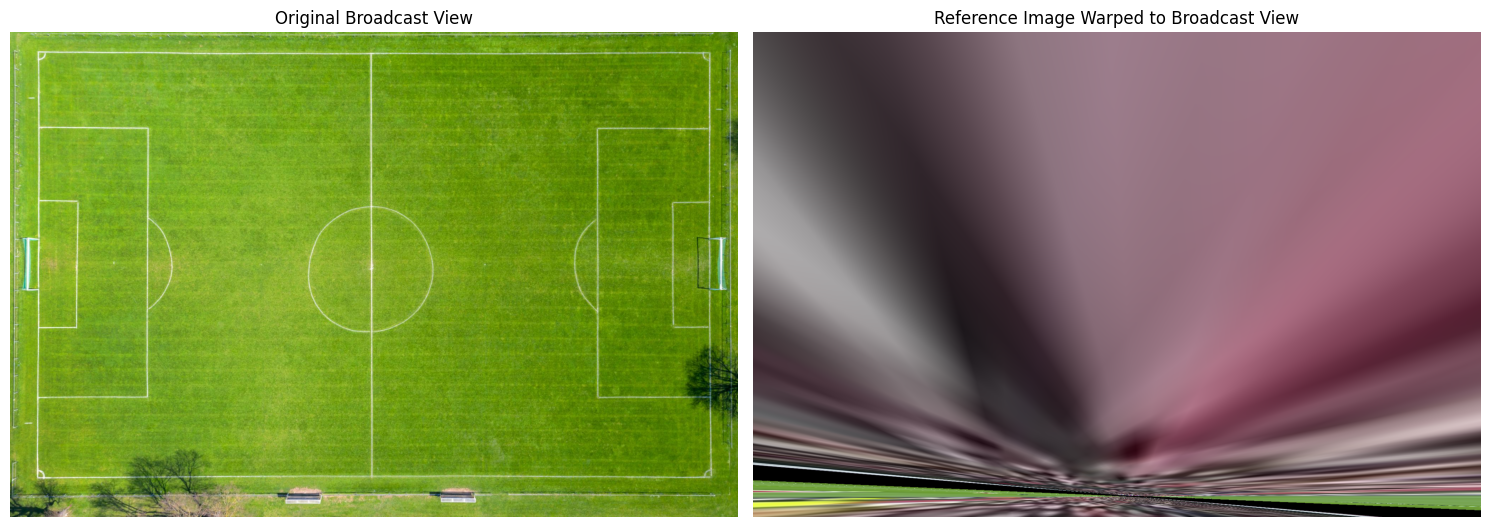

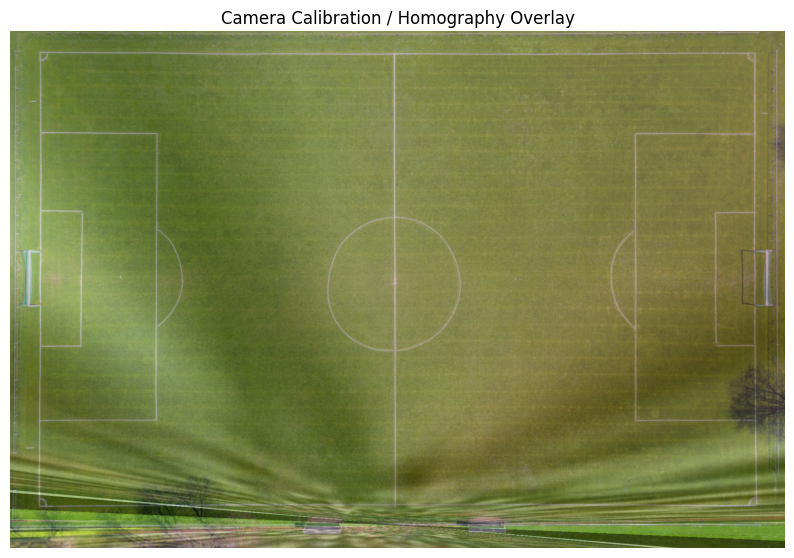


========== REPROJECTION ERROR ==========
Mean reprojection error: 0.0000 pixels
Median reprojection error: 0.0000 pixels
Maximum reprojection error: 0.0000 pixels


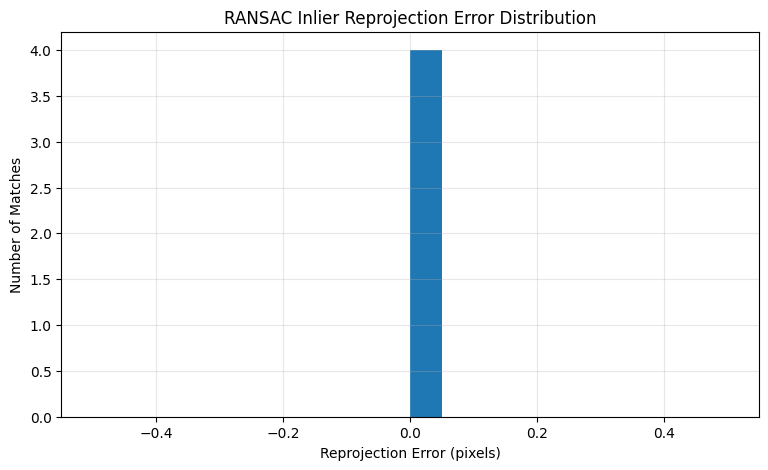


FINAL PERFORMANCE SUMMARY
Reference SIFT keypoints : 3000
Broadcast SIFT keypoints : 3000
Candidate matches        : 3000
Good matches             : 10
RANSAC inliers           : 4
RANSAC outliers          : 6
Inlier ratio             : 40.00%
Mean reprojection error  : 0.0000 pixels
Median reprojection error: 0.0000 pixels
Maximum reprojection error: 0.0000 pixels

========== INTERPRETATION ==========
The inlier ratio is relatively low. The input images may have insufficient overlap or repetitive/ambiguous features.

Lower reprojection error indicates better geometric alignment between corresponding features.

The estimated homography can be used to map the reference sports-field view into the broadcast view.

Feature-matching-based camera calibration completed successfully.


In [1]:
# ==========================================================
# CO3 - AT2 - QUESTION 31
# Feature Matching for Sports Broadcast Camera Calibration
# ==========================================================

# ==========================================================
# 1. INSTALL / IMPORT LIBRARIES
# ==========================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

print("OpenCV version:", cv2.__version__)

# ==========================================================
# 2. UPLOAD TWO IMAGES
# ==========================================================

print("\nUpload TWO images:")
print("1. Reference sports-field image")
print("2. Broadcast sports-field image")

uploaded = files.upload()

if len(uploaded) < 2:
    raise ValueError(
        "Please upload exactly two images."
    )

filenames = list(uploaded.keys())

print("\nUploaded files:")

for name in filenames:
    print("-", name)

# ==========================================================
# 3. READ IMAGES
# ==========================================================

reference_name = filenames[0]
broadcast_name = filenames[1]

reference = cv2.imread(
    reference_name
)

broadcast = cv2.imread(
    broadcast_name
)

if reference is None:
    raise ValueError(
        "Unable to read the reference image."
    )

if broadcast is None:
    raise ValueError(
        "Unable to read the broadcast image."
    )

print(
    "\nReference image size:",
    reference.shape[1],
    "x",
    reference.shape[0]
)

print(
    "Broadcast image size:",
    broadcast.shape[1],
    "x",
    broadcast.shape[0]
)

# ==========================================================
# 4. CONVERT TO GRAYSCALE
# ==========================================================

reference_gray = cv2.cvtColor(
    reference,
    cv2.COLOR_BGR2GRAY
)

broadcast_gray = cv2.cvtColor(
    broadcast,
    cv2.COLOR_BGR2GRAY
)

# ==========================================================
# 5. CREATE SIFT DETECTOR
# ==========================================================

sift = cv2.SIFT_create(
    nfeatures=3000
)

# ==========================================================
# 6. DETECT SIFT KEYPOINTS AND DESCRIPTORS
# ==========================================================

reference_keypoints, reference_descriptors = (
    sift.detectAndCompute(
        reference_gray,
        None
    )
)

broadcast_keypoints, broadcast_descriptors = (
    sift.detectAndCompute(
        broadcast_gray,
        None
    )
)

if reference_descriptors is None:
    raise ValueError(
        "No SIFT features detected in the reference image."
    )

if broadcast_descriptors is None:
    raise ValueError(
        "No SIFT features detected in the broadcast image."
    )

print("\n========== SIFT FEATURE DETECTION ==========")

print(
    "Reference keypoints:",
    len(reference_keypoints)
)

print(
    "Broadcast keypoints:",
    len(broadcast_keypoints)
)

# ==========================================================
# 7. VISUALIZE SIFT KEYPOINTS
# ==========================================================

reference_keypoint_image = cv2.drawKeypoints(
    reference,
    reference_keypoints,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

broadcast_keypoint_image = cv2.drawKeypoints(
    broadcast,
    broadcast_keypoints,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.figure(
    figsize=(16, 7)
)

plt.subplot(
    1,
    2,
    1
)

plt.imshow(
    cv2.cvtColor(
        reference_keypoint_image,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    "Reference Image - SIFT Keypoints"
)

plt.axis("off")

plt.subplot(
    1,
    2,
    2
)

plt.imshow(
    cv2.cvtColor(
        broadcast_keypoint_image,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    "Broadcast Image - SIFT Keypoints"
)

plt.axis("off")

plt.tight_layout()

plt.show()

# ==========================================================
# 8. SIFT FEATURE MATCHING
# ==========================================================

# FLANN parameters
index_params = dict(
    algorithm=1,
    trees=5
)

search_params = dict(
    checks=100
)

flann = cv2.FlannBasedMatcher(
    index_params,
    search_params
)

matches = flann.knnMatch(
    reference_descriptors,
    broadcast_descriptors,
    k=2
)

# ==========================================================
# 9. LOWE'S RATIO TEST
# ==========================================================

RATIO_THRESHOLD = 0.75

good_matches = []

for pair in matches:

    if len(pair) != 2:
        continue

    m, n = pair

    if m.distance < RATIO_THRESHOLD * n.distance:
        good_matches.append(m)

print(
    "\n========== FEATURE MATCHING =========="
)

print(
    "Total candidate matches:",
    len(matches)
)

print(
    "Good matches after Lowe's ratio test:",
    len(good_matches)
)

if len(good_matches) < 4:

    raise ValueError(
        "Not enough good matches for homography estimation.\n"
        "Use images with more overlapping field features "
        "or reduce the ratio threshold slightly."
    )

# ==========================================================
# 10. VISUALIZE GOOD MATCHES
# ==========================================================

good_match_image = cv2.drawMatches(
    reference,
    reference_keypoints,
    broadcast,
    broadcast_keypoints,
    good_matches,
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(
    figsize=(18, 8)
)

plt.imshow(
    cv2.cvtColor(
        good_match_image,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    "SIFT Matches After Lowe's Ratio Test"
)

plt.axis("off")

plt.show()

# ==========================================================
# 11. PREPARE POINT CORRESPONDENCES
# ==========================================================

reference_points = np.float32(
    [
        reference_keypoints[m.queryIdx].pt
        for m in good_matches
    ]
).reshape(-1, 1, 2)

broadcast_points = np.float32(
    [
        broadcast_keypoints[m.trainIdx].pt
        for m in good_matches
    ]
).reshape(-1, 1, 2)

# ==========================================================
# 12. RANSAC HOMOGRAPHY ESTIMATION
# ==========================================================

RANSAC_THRESHOLD = 5.0

H, mask = cv2.findHomography(
    reference_points,
    broadcast_points,
    cv2.RANSAC,
    RANSAC_THRESHOLD
)

if H is None:
    raise ValueError(
        "Homography could not be estimated."
    )

# ==========================================================
# 13. INLIER / OUTLIER ANALYSIS
# ==========================================================

inlier_mask = mask.ravel().astype(bool)

inlier_count = np.sum(
    inlier_mask
)

outlier_count = (
    len(good_matches)
    -
    inlier_count
)

inlier_ratio = (
    inlier_count /
    len(good_matches)
)

print(
    "\n========== RANSAC RESULTS =========="
)

print(
    "Good matches:",
    len(good_matches)
)

print(
    "RANSAC inliers:",
    inlier_count
)

print(
    "RANSAC outliers:",
    outlier_count
)

print(
    "Inlier ratio:",
    f"{inlier_ratio:.4f}"
)

print(
    "Inlier ratio (%):",
    f"{inlier_ratio * 100:.2f}%"
)

# ==========================================================
# 14. VISUALIZE RANSAC INLIER MATCHES
# ==========================================================

inlier_matches = [
    m
    for i, m in enumerate(good_matches)
    if inlier_mask[i]
]

inlier_match_image = cv2.drawMatches(
    reference,
    reference_keypoints,
    broadcast,
    broadcast_keypoints,
    inlier_matches,
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(
    figsize=(18, 8)
)

plt.imshow(
    cv2.cvtColor(
        inlier_match_image,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    "RANSAC Inlier Matches Used for Camera Calibration"
)

plt.axis("off")

plt.show()

# ==========================================================
# 15. WARP REFERENCE IMAGE TO BROADCAST VIEW
# ==========================================================

height, width = broadcast.shape[:2]

warped_reference = cv2.warpPerspective(
    reference,
    H,
    (width, height)
)

plt.figure(
    figsize=(15, 6)
)

plt.subplot(
    1,
    2,
    1
)

plt.imshow(
    cv2.cvtColor(
        broadcast,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    "Original Broadcast View"
)

plt.axis("off")

plt.subplot(
    1,
    2,
    2
)

plt.imshow(
    cv2.cvtColor(
        warped_reference,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    "Reference Image Warped to Broadcast View"
)

plt.axis("off")

plt.tight_layout()

plt.show()

# ==========================================================
# 16. CAMERA CALIBRATION VISUALIZATION
# ==========================================================

# Overlay warped reference and broadcast image

broadcast_float = broadcast.astype(
    np.float32
)

warped_float = warped_reference.astype(
    np.float32
)

overlay = cv2.addWeighted(
    broadcast_float,
    0.5,
    warped_float,
    0.5,
    0
)

overlay = np.clip(
    overlay,
    0,
    255
).astype(
    np.uint8
)

plt.figure(
    figsize=(10, 7)
)

plt.imshow(
    cv2.cvtColor(
        overlay,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    "Camera Calibration / Homography Overlay"
)

plt.axis("off")

plt.show()

# ==========================================================
# 17. REPROJECTION ERROR
# ==========================================================

# Transform reference points using homography

projected_points = cv2.perspectiveTransform(
    reference_points,
    H
)

# Calculate Euclidean reprojection errors

errors = np.linalg.norm(
    projected_points -
    broadcast_points,
    axis=2
).ravel()

# Only use RANSAC inliers for the calibration error

inlier_errors = errors[
    inlier_mask
]

mean_reprojection_error = np.mean(
    inlier_errors
)

median_reprojection_error = np.median(
    inlier_errors
)

max_reprojection_error = np.max(
    inlier_errors
)

print(
    "\n========== REPROJECTION ERROR =========="
)

print(
    "Mean reprojection error:",
    f"{mean_reprojection_error:.4f} pixels"
)

print(
    "Median reprojection error:",
    f"{median_reprojection_error:.4f} pixels"
)

print(
    "Maximum reprojection error:",
    f"{max_reprojection_error:.4f} pixels"
)

# ==========================================================
# 18. ERROR DISTRIBUTION
# ==========================================================

plt.figure(
    figsize=(9, 5)
)

plt.hist(
    inlier_errors,
    bins=20
)

plt.xlabel(
    "Reprojection Error (pixels)"
)

plt.ylabel(
    "Number of Matches"
)

plt.title(
    "RANSAC Inlier Reprojection Error Distribution"
)

plt.grid(
    True,
    alpha=0.3
)

plt.show()

# ==========================================================
# 19. FINAL PERFORMANCE SUMMARY
# ==========================================================

print(
    "\n===================================================="
)

print(
    "FINAL PERFORMANCE SUMMARY"
)

print(
    "===================================================="
)

print(
    f"Reference SIFT keypoints : "
    f"{len(reference_keypoints)}"
)

print(
    f"Broadcast SIFT keypoints : "
    f"{len(broadcast_keypoints)}"
)

print(
    f"Candidate matches        : "
    f"{len(matches)}"
)

print(
    f"Good matches             : "
    f"{len(good_matches)}"
)

print(
    f"RANSAC inliers           : "
    f"{inlier_count}"
)

print(
    f"RANSAC outliers          : "
    f"{outlier_count}"
)

print(
    f"Inlier ratio             : "
    f"{inlier_ratio * 100:.2f}%"
)

print(
    f"Mean reprojection error  : "
    f"{mean_reprojection_error:.4f} pixels"
)

print(
    f"Median reprojection error: "
    f"{median_reprojection_error:.4f} pixels"
)

print(
    f"Maximum reprojection error: "
    f"{max_reprojection_error:.4f} pixels"
)

print(
    "===================================================="
)

# ==========================================================
# 20. INTERPRETATION
# ==========================================================

print(
    "\n========== INTERPRETATION =========="
)

if inlier_ratio >= 0.70:

    print(
        "A high proportion of matches are geometrically "
        "consistent with the estimated transformation."
    )

elif inlier_ratio >= 0.50:

    print(
        "A moderate proportion of matches are "
        "geometrically consistent."
    )

else:

    print(
        "The inlier ratio is relatively low. "
        "The input images may have insufficient overlap "
        "or repetitive/ambiguous features."
    )

print(
    "\nLower reprojection error indicates better "
    "geometric alignment between corresponding features."
)

print(
    "\nThe estimated homography can be used to map "
    "the reference sports-field view into the broadcast view."
)

print(
    "\nFeature-matching-based camera calibration "
    "completed successfully."
)